# HybridEnhancementNet
Low-light image enhancement for exploration rover deployment.

**Pipeline:**
1. Environment setup (Drive + GitHub + packages)
2. Dataset download (LOL + DarkFace via Kaggle)
3. LOL supervised training
4. DarkFace self-supervised training
5. Evaluation + export
6. Push results to GitHub

## 1. Environment Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
import os

REPO_URL = 'https://github.com/BubbleGum-git/HybridEnhancementNet.git'
REPO_DIR = '/content/HybridEnhancementNet'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}
!pip install -r requirements.txt -q

Already up to date.
/content/HybridEnhancementNet


In [25]:
import sys
sys.path.append('/content/HybridEnhancementNet')

import yaml, torch
from src.utils import load_config, setup_kaggle_credentials, download_datasets, make_drive_dirs, get_device

cfg    = load_config('config.yaml')
device = get_device()

setup_kaggle_credentials(cfg['paths']['kaggle_json'])
make_drive_dirs(cfg)

print('Environment ready.')

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB
Kaggle credentials loaded from /content/drive/MyDrive/kaggle.json
Created: /content/drive/MyDrive/HybridEnhancementNet/checkpoints
Created: /content/drive/MyDrive/HybridEnhancementNet/results
Environment ready.


## 2. Download Datasets

In [6]:
from src.utils import download_datasets
lol_path, darkface_path = download_datasets(cfg)
print(f'LOL path     : {lol_path}')
print(f'DarkFace path: {darkface_path}')

100%|██████████| 331M/331M [00:09<00:00, 38.5MB/s]

Extracting files...


  LOL raw path: /root/.cache/kagglehub/datasets/soumikrakshit/lol-dataset/versions/1


100%|██████████| 4.08G/4.08G [01:49<00:00, 40.0MB/s]

Extracting files...


  DarkFace raw path: /root/.cache/kagglehub/datasets/soumikrakshit/dark-face-dataset/versions/1
Copying LOL dataset to /content/dataset/lol_dataset...
Copying DarkFace dataset to /content/darkface_dataset...
Datasets ready.
LOL path     : /content/dataset/lol_dataset
DarkFace path: /content/darkface_dataset


## 3. LOL Supervised Training

LOLDataset (train): 485 pairs


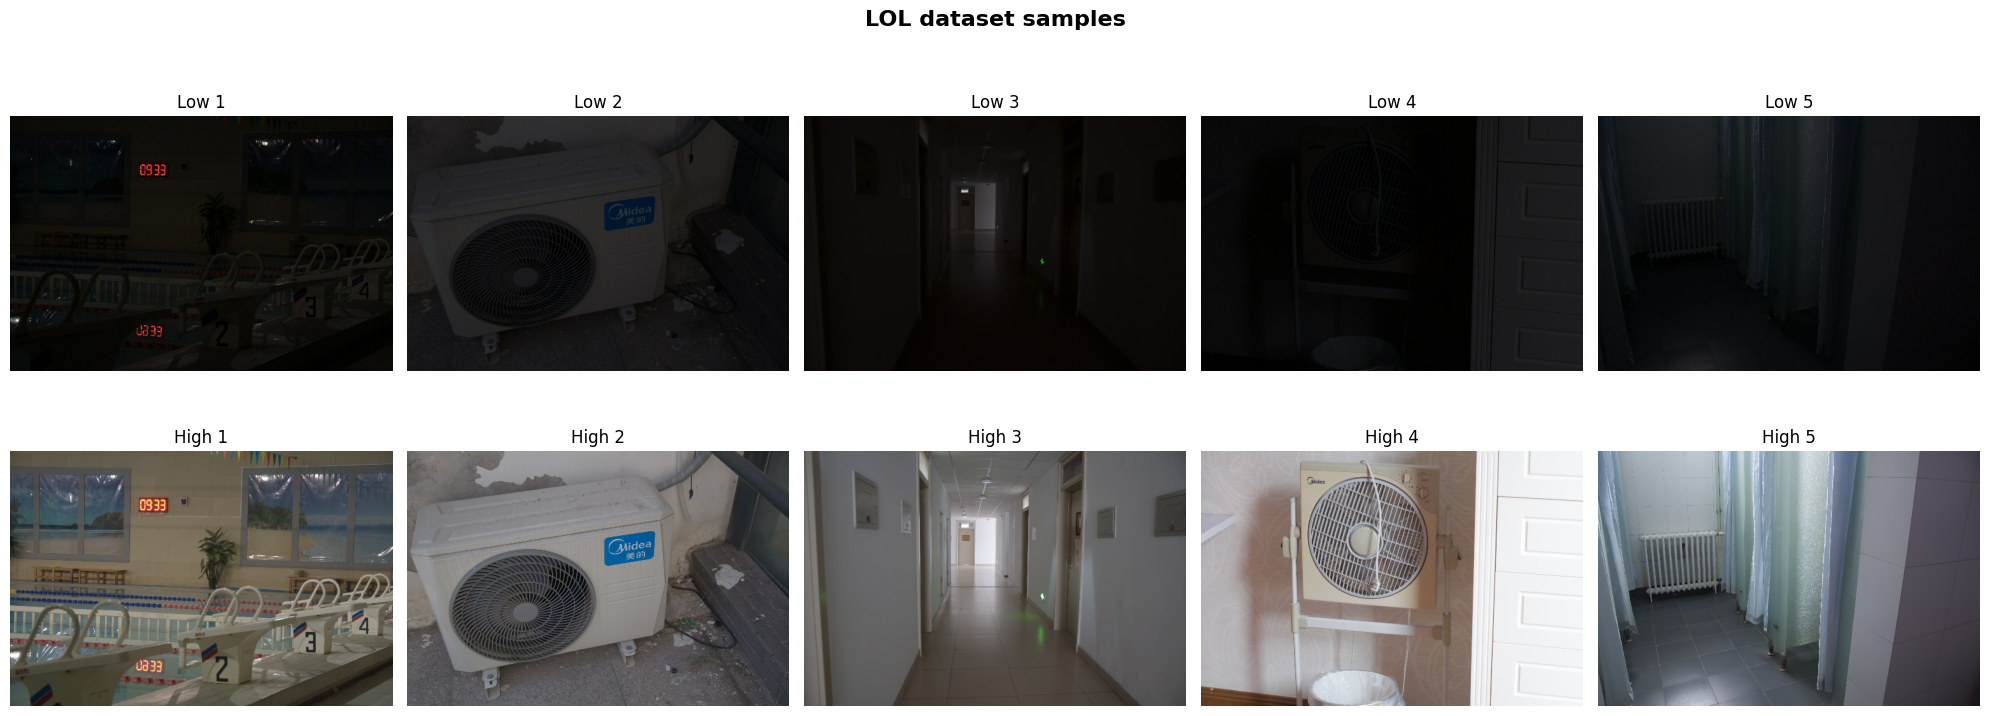

Saved /content/drive/MyDrive/HybridEnhancementNet/results/lol_samples.png
Train: 388 | Val: 97


In [26]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from src.dataset import LOLDataset
from src.model import HybridEnhancementNet
from src.evaluate import visualize_dataset_samples

lol_cfg   = cfg['training']['lol']
transform = transforms.Compose([transforms.ToTensor()])

full_dataset = LOLDataset('/content/dataset/lol_dataset/lol_dataset', transform=transform, train=True)
visualize_dataset_samples(full_dataset,
                          save_path=cfg['paths']['results'] + '/lol_samples.png',
                          title='LOL dataset samples',
                          paired=True)

train_size = int(lol_cfg['train_split'] * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_set, val_set = random_split(full_dataset, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(lol_cfg['seed']))

train_loader = DataLoader(train_set, batch_size=lol_cfg['batch_size'], shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=lol_cfg['batch_size'], shuffle=False, num_workers=2)

print(f'Train: {len(train_set)} | Val: {len(val_set)}')

In [30]:
from src.train import train_lol, save_metrics_csv, print_metrics_table
from src.evaluate import compute_psnr_mse, visualize_enhancement, plot_training_curves

lol_model = HybridEnhancementNet().to(device)

train_losses, val_losses, lrs, psnrs, ssims = train_lol(
    lol_model, train_loader, val_loader, device,
    cfg=lol_cfg,
    save_dir=cfg['paths']['checkpoints']
)

print(f"Best PSNR : {max(psnrs):.2f} dB")
print(f"Best SSIM : {max(ssims):.4f}")

plot_training_curves(
    train_losses, val_losses, lrs,
    save_path=cfg['paths']['results'] + '/lol_training_history.png',
    title='LOL Training History'
)

mse, psnr = compute_psnr_mse(lol_model, val_loader, device, paired=True)
visualize_enhancement(
    lol_model, val_loader, device,
    save_path=cfg['paths']['results'] + '/lol_results.png',
    tag='LOL final',
    paired=True
)


Epoch 1/200
   Train Loss : 0.044179
   Val Loss   : 0.034638
   LR         : 1.00e-03
   Time       : 26.7s
   Saved best model (val loss: 0.034638)



Epoch 2/200
   Train Loss : 0.028760
   Val Loss   : 0.039298
   LR         : 1.00e-03
   Time       : 27.0s



Epoch 3/200
   Train Loss : 0.025857
   Val Loss   : 0.025295
   LR         : 1.00e-03
   Time       : 26.3s
   Saved best model (val loss: 0.025295)



Epoch 4/200
   Train Loss : 0.024980
   Val Loss   : 0.025774
   LR         : 1.00e-03
   Time       : 25.6s



Epoch 5/200
   Train Loss : 0.024595
   Val Loss   : 0.026250
   LR         : 1.00e-03
   Time       : 25.7s


...


Epoch 196/200
   Train Loss : 0.018004
   Val Loss   : 0.018974
   LR         : 9.77e-07
   Time       : 25.8s



Epoch 197/200
   Train Loss : 0.018105
   Val Loss   : 0.018981
   LR         : 9.77e-07
   Time       : 26.0s



Epoch 198/200
   Train Loss : 0.018120
   Val Loss   : 0.018969
   LR         : 9.77e-07
   Time       : 25.6s



Epoch 199/200
   Train Loss : 0.018000
   Val Loss   : 0.018984
   LR         : 4.88e-07
   Time       : 25.7s



Epoch 200/200
   Train Loss : 0.018160
   Val Loss   : 0.018980
   LR         : 4.88e-07
   Time       : 26.4s

Saved final_model.pth to /content/drive/MyDrive/HybridEnhancementNet/checkpoints
Saved /content/drive/MyDrive/HybridEnhancementNet/results/lol_training_history.png
Test Results — MSE: 0.019224  PSNR: 17.16 dB
Saved /content/drive/MyDrive/HybridEnhancementNet/results/lol_results.png


## 4. DarkFace Self-Supervised Training

In [ ]:
from torch.utils.data import random_split
from src.dataset import DarkFaceDataset, darkface_collate_fn
from src.utils import preflight_check

df_cfg = cfg['training']['darkface']
preflight_check(darkface_path)

df_dataset = DarkFaceDataset(darkface_path, transform=transform)

train_sz = int(df_cfg['train_split'] * len(df_dataset))
test_sz  = len(df_dataset) - train_sz
df_train, df_test = random_split(df_dataset, [train_sz, test_sz],
                                  generator=torch.Generator().manual_seed(df_cfg['seed']))

df_train_loader = DataLoader(df_train, batch_size=df_cfg['batch_size'], shuffle=True,
                              collate_fn=darkface_collate_fn)
df_test_loader  = DataLoader(df_test,  batch_size=df_cfg['batch_size'], shuffle=False,
                              collate_fn=darkface_collate_fn)

print(f'DarkFace Train: {train_sz} | Test: {test_sz}')

In [ ]:
from src.train import train_darkface, print_metrics_table, save_metrics_csv

df_model    = HybridEnhancementNet().to(device)
metrics_log = []

train_losses, lrs = train_darkface(
    df_model, df_train_loader, df_test_loader, device,
    cfg=df_cfg,
    save_dir=cfg['paths']['checkpoints'],
    vis_interval=df_cfg['vis_interval'],
    metrics_log=metrics_log
)

plot_training_curves(
    train_losses, [], lrs,
    save_path=cfg['paths']['results'] + '/darkface_training_history.png',
    title='DarkFace Training History'
)

print_metrics_table(metrics_log)
save_metrics_csv(metrics_log, cfg['paths']['results'] + '/metrics.csv')

## 5. Export Model for Rover

In [ ]:
from deploy.export_onnx import export_onnx

export_onnx(
    checkpoint_path=cfg['paths']['checkpoints'] + '/best_model.pth',
    output_path=cfg['paths']['drive_base'] + '/exported/model.onnx',
    input_h=cfg['deploy']['input_size'][1],
    input_w=cfg['deploy']['input_size'][2]
)

## 6. Push to GitHub